In [ ]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
dpe_eda=pd.read_csv('df_enedis_eda.csv')

In [94]:
dpe_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4764358 entries, 0 to 4764357
Data columns (total 33 columns):
 #   Column                             Dtype  
---  ------                             -----  
 0   adresse_ban                        object 
 1   code_insee_ban                     object 
 2   nom_commune_ban                    object 
 3   coordonnee_cartographique_x_ban    float64
 4   coordonnee_cartographique_y_ban    float64
 5   annee_construction                 float64
 6   type_batiment                      object 
 7   surface_habitable_logement         float64
 8   etiquette_dpe                      object 
 9   type_energie_principale_chauffage  object 
 10  type_energie_principale_ecs        object 
 11  type_installation_chauffage        object 
 12  type_installation_chauffage.1      object 
 13  conso_5_usages_ef                  float64
 14  conso_5_usages_par_m2_ef           float64
 15  conso_chauffage_ef                 float64
 16  conso_ecs_ef      

# Netoyage des données

### Conversion des types de variables

#### Les Dates

In [95]:
dpe_eda['date_etablissement_dpe'] = pd.to_datetime(dpe_eda['date_etablissement_dpe'], errors='coerce')

#### Les Variables numériques

In [96]:
num_variables=['surface_habitable_logement',
    'annee_construction',
    'conso_5_usages_ef',
    'coordonnee_cartographique_x_ban',
    'coordonnee_cartographique_y_ban']

for i in num_variables:
    dpe_eda[i]=pd.to_numeric(dpe_eda[i], errors='coerce')

#### Les codes géographiques

In [97]:
dpe_eda['code_insee_ban'] = dpe_eda['code_insee_ban'].astype(str)

#### Les classes DPE doivent être A → G.

In [98]:
classes_valides=list('A,B,C,D,E,F,G')
dpe_eda=dpe_eda[dpe_eda['etiquette_dpe'].isin(classes_valides)]

#### Encodage des étiquettes DPE

In [99]:
dpe_map = {
    'A':7,
    'B':6,
    'C':5,
    'D':4,
    'E':3,
    'F':2,
    'G':1
}

dpe_eda['score_dpe'] = dpe_eda['etiquette_dpe'].map(dpe_map)

#### Surface habitable
On supprime les surfaces absurdes.

In [100]:
dpe_eda=dpe_eda[dpe_eda['surface_habitable_logement']>5]

#### Consommation énergetique

In [101]:
dpe_eda = dpe_eda[(dpe_eda['conso_5_usages_ef'] > 0)]

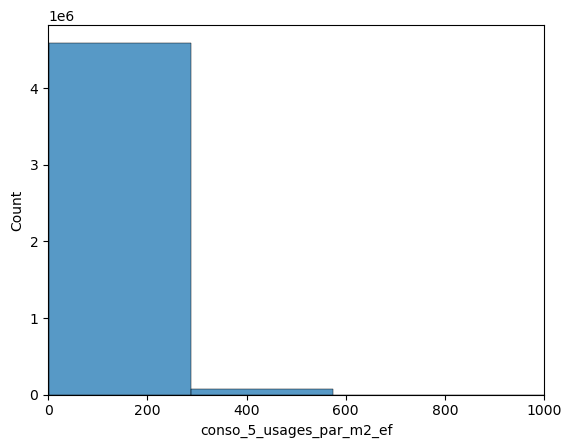

In [102]:
sns.histplot(dpe_eda["conso_5_usages_par_m2_ef"], bins=100)
plt.xlim(0,1000)
plt.show()

In [103]:
dpe_eda=dpe_eda[(dpe_eda["conso_5_usages_par_m2_ef"] >20)& (dpe_eda["conso_5_usages_par_m2_ef"] < 600)]

### Gestion des valeurs manquantes

Nous avons déjà supprimer pas mal de valeurs manquantes avec les filtrages sur nos variables indispensables. Nous allons maintenant imputer ou supprimer les restantes

In [104]:
dpe_eda.isna().sum()

adresse_ban                            63072
code_insee_ban                             0
nom_commune_ban                        60980
coordonnee_cartographique_x_ban        60980
coordonnee_cartographique_y_ban        60980
annee_construction                   2188102
type_batiment                              0
surface_habitable_logement                 0
etiquette_dpe                              0
type_energie_principale_chauffage          0
type_energie_principale_ecs                0
type_installation_chauffage          1562628
type_installation_chauffage.1        1562628
conso_5_usages_ef                          0
conso_5_usages_par_m2_ef                   0
conso_chauffage_ef                         0
conso_ecs_ef                               0
conso_eclairage_ef                         0
conso_refroidissement_ef                   0
conso_auxiliaires_ef                       0
deperditions_enveloppe                     0
deperditions_murs                          4
deperditio

Vu le nombre de valeurs manquantes importantes sur la variable année de contruction, nous les imputer plutôt que de les supprimer.

Les variables type_installation_chauffage.1, type_installation_chauffage.1 et indicateur_confort_ete seront supprimées.
Les données manquantes sur les variables localisation((nom_commune_ban,coordonnee_cartographique_x_ban,coordonnee_cartographique_y_ban)) seront toutes supprimées, ce sont les mêmes lignes

Nous allons imputer les Na des variables de deperditions seront imputer par la mediane
Avec les adresses brutes, nous pouvons bien avoir les adresses_ban manquantes mais vu la taille de notre jeu de données on a préféré de les supprimer(plus facile , pas forcement la meilleure ici)

In [105]:
def periode_construction(x):
    if pd.isna(x):
        return "Inconnue"
    elif x < 1948:
        return "Avant 1948"
    elif x < 1975:
        return "1948-1974"
    elif x < 1990:
        return "1975-1989"
    elif x < 2001:
        return "1990-2000"
    elif x < 2006:
        return "2001-2005"
    elif x < 2013:
        return "2006-2012"
    elif x < 2022:
        return "2013-2021"
    else:
        return "Après 2021"

dpe_eda["periode_construction"] = dpe_eda["annee_construction"].apply(periode_construction)
dpe_eda = dpe_eda.drop(columns=["annee_construction"])

In [106]:
dpe_eda=dpe_eda.drop(columns=['type_installation_chauffage', 'type_installation_chauffage.1' , 'indicateur_confort_ete'])

In [107]:
dpe_eda=dpe_eda.dropna(subset=['nom_commune_ban', 'coordonnee_cartographique_x_ban', 'coordonnee_cartographique_y_ban','adresse_ban'])

In [108]:
# imputation par inconnu
dpe_eda['qualite_isolation_murs'] = dpe_eda['qualite_isolation_murs'].fillna(dpe_eda['qualite_isolation_murs']=='Inconnue')

In [109]:
# imputation par la mediane
variables=['deperditions_enveloppe','deperditions_murs','deperditions_planchers_hauts']
for i in variables:
    dpe_eda[i] = dpe_eda[i].fillna(dpe_eda[i].median())

In [110]:
variables_cout=['cout_chauffage','cout_ecs','cout_refroidissement','cout_total_5_usages']
dpe_eda = dpe_eda.dropna(subset=variables_cout)

In [111]:
dpe_eda.isna().sum()

adresse_ban                          0
code_insee_ban                       0
nom_commune_ban                      0
coordonnee_cartographique_x_ban      0
coordonnee_cartographique_y_ban      0
type_batiment                        0
surface_habitable_logement           0
etiquette_dpe                        0
type_energie_principale_chauffage    0
type_energie_principale_ecs          0
conso_5_usages_ef                    0
conso_5_usages_par_m2_ef             0
conso_chauffage_ef                   0
conso_ecs_ef                         0
conso_eclairage_ef                   0
conso_refroidissement_ef             0
conso_auxiliaires_ef                 0
deperditions_enveloppe               0
deperditions_murs                    0
deperditions_planchers_bas           0
deperditions_planchers_hauts         0
qualite_isolation_murs               0
qualite_isolation_enveloppe          0
zone_climatique                      0
date_etablissement_dpe               0
cout_total_5_usages      

#### Les doublons

In [112]:
dpe_eda.duplicated().sum()

268953

In [113]:
dpe_eda=dpe_eda.drop_duplicates()

### Vérification finale

In [114]:
print(dpe_eda.info())
print(dpe_eda.describe())
print(dpe_eda.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 4317730 entries, 0 to 4764357
Data columns (total 31 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   adresse_ban                        object        
 1   code_insee_ban                     object        
 2   nom_commune_ban                    object        
 3   coordonnee_cartographique_x_ban    float64       
 4   coordonnee_cartographique_y_ban    float64       
 5   type_batiment                      object        
 6   surface_habitable_logement         float64       
 7   etiquette_dpe                      object        
 8   type_energie_principale_chauffage  object        
 9   type_energie_principale_ecs        object        
 10  conso_5_usages_ef                  float64       
 11  conso_5_usages_par_m2_ef           float64       
 12  conso_chauffage_ef                 float64       
 13  conso_ecs_ef                       float64       
 14  conso_e

### Dataset final

In [ ]:
df_clean = dpe_eda.copy()
# df_clean.to_csv('df_dpe_clean.csv', index=False)

## CONSOMMATION ENEDIS

In [116]:
df_consommation=pd.read_csv("consommation-annuelle-residentielle-par-adresse (1).csv" ,sep=";")
df_consommation=df_consommation[df_consommation["Année"]>2020] 

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_1060\3711420648.py:1: DtypeWarning: Columns (1,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df_consommation=pd.read_csv("consommation-annuelle-residentielle-par-adresse (1).csv" ,sep=";")


Nous filtrons Année sur 2020 comme demander dans les consignes (puisqu'on travaille sur les données de DPE disponible qu'à partir de juillet 2021)

In [117]:
df_consommation.head()

,Année,Code IRIS,Nom IRIS,Numéro de voie,Indice de répétition,Type de voie,Libellé de voie,Code Commune,Nom Commune,Segment de client,Nombre de logements,Consommation annuelle totale de l'adresse (MWh),Consommation annuelle moyenne par logement de l'adresse (MWh),Consommation annuelle moyenne de la commune (MWh),Adresse,Code EPCI,Code Département,Code Région,Tri des adresses
142030,2021,340030101,Vielle Ville-Pérou-Gare,2.0,NaN,RUE,RABELAIS,34003,Agde,RESIDENTIEL,11,51.359,4.669,2.688,2 RUE RABELAIS,243400819.0,34.0,76.0,1008
142031,2021,340030201,Le Cap d'Agde,29.0,NaN,PLACE,TERRISSE,34003,Agde,RESIDENTIEL,12,18.491,1.541,2.688,29 PLACE TERRISSE,243400819.0,34.0,76.0,1028
142032,2021,340030103,Les Cayrets,8.0,NaN,RUE,VICTOR POUGET,34003,Agde,RESIDENTIEL,17,33.123,1.948,2.688,8 RUE VICTOR POUGET,243400819.0,34.0,76.0,1034
142033,2021,470010111,Montanou,5.0,NaN,RUE,BLAISE DE MONLUC,47001,Agen,RESIDENTIEL,56,83.869,1.498,3.198,5 RUE BLAISE DE MONLUC,200096956.0,47.0,75.0,1058
142034,2021,470010101,Centre Urbain 1,117.0,NaN,BOULEVARD,CARNOT,47001,Agen,RESIDENTIEL,27,31.891,1.181,3.198,117 BOULEVARD CARNOT,200096956.0,47.0,75.0,1065


In [118]:
cols_enedis = [
    "Code Commune",
    "Nom Commune",
    "Adresse",
    "Année",
    "Segment de client",
    "Consommation annuelle totale de l'adresse (MWh)",
    "Consommation annuelle moyenne par logement de l'adresse (MWh)",
    'Consommation annuelle moyenne de la commune (MWh)',
    "Nombre de logements"
]

df_consommation = df_consommation[cols_enedis]

In [119]:
df_consommation.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1625434 entries, 142030 to 2821928
Data columns (total 9 columns):
 #   Column                                                         Non-Null Count    Dtype  
---  ------                                                         --------------    -----  
 0   Code Commune                                                   1625434 non-null  int64  
 1   Nom Commune                                                    1625434 non-null  object 
 2   Adresse                                                        1625434 non-null  object 
 3   Année                                                          1625434 non-null  int64  
 4   Segment de client                                              1625434 non-null  object 
 5   Consommation annuelle totale de l'adresse (MWh)                1625434 non-null  float64
 6   Consommation annuelle moyenne par logement de l'adresse (MWh)  1625434 non-null  float64
 7   Consommation annuelle moyenne de la c

In [120]:
df_consommation.isna().sum()

Code Commune                                                     0
Nom Commune                                                      0
Adresse                                                          0
Année                                                            0
Segment de client                                                0
Consommation annuelle totale de l'adresse (MWh)                  0
Consommation annuelle moyenne par logement de l'adresse (MWh)    0
Consommation annuelle moyenne de la commune (MWh)                0
Nombre de logements                                              0
dtype: int64

In [121]:
df_consommation.duplicated().sum()

0

A priori pas de doublons, ni de valeurs manquantes.

Nettoyage des types

In [122]:
df_consommation["Année"] = pd.to_numeric(df_consommation["Année"], errors="coerce")

df_consommation["Consommation annuelle moyenne par logement de l'adresse (MWh)"] = pd.to_numeric(
    df_consommation["Consommation annuelle moyenne par logement de l'adresse (MWh)"], errors="coerce"
)

df_consommation["Consommation annuelle totale de l'adresse (MWh)"] = pd.to_numeric(
    df_consommation["Consommation annuelle totale de l'adresse (MWh)"], errors="coerce"
)


df_consommation["Consommation annuelle moyenne de la commune (MWh)"] = pd.to_numeric(
    df_consommation["Consommation annuelle moyenne de la commune (MWh)"], errors="coerce"
)


df_consommation["Nombre de logements"] = pd.to_numeric(df_consommation["Nombre de logements"], errors="coerce")

df_consommation["Code Commune"] = df_consommation["Code Commune"].astype(str)


#### Standardiser les noms de communes

In [123]:
df_consommation["Nom Commune"] = (
    df_consommation["Nom Commune"]
    .str.upper()
    .str.strip()
)

In [124]:
df_consommation.head()

,Code Commune,Nom Commune,Adresse,Année,Segment de client,Consommation annuelle totale de l'adresse (MWh),Consommation annuelle moyenne par logement de l'adresse (MWh),Consommation annuelle moyenne de la commune (MWh),Nombre de logements
142030,34003,AGDE,2 RUE RABELAIS,2021,RESIDENTIEL,51.359,4.669,2.688,11
142031,34003,AGDE,29 PLACE TERRISSE,2021,RESIDENTIEL,18.491,1.541,2.688,12
142032,34003,AGDE,8 RUE VICTOR POUGET,2021,RESIDENTIEL,33.123,1.948,2.688,17
142033,47001,AGEN,5 RUE BLAISE DE MONLUC,2021,RESIDENTIEL,83.869,1.498,3.198,56
142034,47001,AGEN,117 BOULEVARD CARNOT,2021,RESIDENTIEL,31.891,1.181,3.198,27


### Vérification finale

In [125]:
print(df_consommation.info())
print(df_consommation.describe())
print(df_consommation.isna().sum())
print(df_consommation.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 1625434 entries, 142030 to 2821928
Data columns (total 9 columns):
 #   Column                                                         Non-Null Count    Dtype  
---  ------                                                         --------------    -----  
 0   Code Commune                                                   1625434 non-null  object 
 1   Nom Commune                                                    1625434 non-null  object 
 2   Adresse                                                        1625434 non-null  object 
 3   Année                                                          1625434 non-null  int64  
 4   Segment de client                                              1625434 non-null  object 
 5   Consommation annuelle totale de l'adresse (MWh)                1625434 non-null  float64
 6   Consommation annuelle moyenne par logement de l'adresse (MWh)  1625434 non-null  float64
 7   Consommation annuelle moyenne de la c

In [ ]:
# df_consommation.to_csv('df_consommation_clean.csv', index=False)

## Préparation de la jointure des deux tables ( Données DPE et Données consommation Enedis)

#### Selection des variables indispensables pour les analyses après jointures dans les données DPE

In [128]:
df_clean=df_clean.drop(columns=['cout_total_5_usages', 'cout_chauffage', 'cout_ecs', 'cout_refroidissement'])

In [129]:
# 1. On ne garde que la partie avant le code postal (rue/numéro)
df_clean["adresse_ban"] = df_clean["adresse_ban"].str.replace(r'\s*\d{5}.*$', '', regex=True).str.strip()

# 2. On reconstruit l'adresse avec les données normalisées
df_clean["Adresse_complete"] = (
    df_clean["adresse_ban"].fillna("") + " " + 
    df_clean["code_insee_ban"].fillna("").astype(str) + " " + 
    df_clean["nom_commune_ban"].fillna("").astype(str).str.upper()
).str.strip()

df_clean["Adresse_complete"]= df_clean["Adresse_complete"].str.upper()


df_consommation["Adresse_complete"]=df_consommation["Adresse"].fillna("").astype(str).str.strip() + " " + df_consommation["Code Commune"].fillna("").astype(str) + " " + df_consommation["Nom Commune"].fillna("").astype(str).str.upper()
df_consommation["Adresse_complete"]= df_consommation["Adresse_complete"].str.upper()

#### Agreggation des données DPE

In [130]:
df_clean['Adresse_complete'].duplicated().sum()

2251829

Plusieurs lignes apparaissent pour une même adresse car un même immeuble contient plusieurs logements distincts partageant exactement la même adresse normalisée.

Chaque logement peut également avoir plusieurs DPE réalisés à des dates différentes, ce qui crée plusieurs enregistrements pour la même adresse.

La BAN supprime les compléments d’adresse (appartement, étage, bâtiment), ce qui regroupe tous les logements d’un immeuble sous une seule adresse.

Ces doublons ne sont pas des erreurs : ils reflètent la structure réelle du parc immobilier. Un immeuble peut contenir de nombreux logements, chacun avec son propre DPE, mais tous rattachés à la même adresse BAN, ce qui entraîne mécaniquement des doublons après la jointure.

Nous allons donc  conserver pour chaque  adresse, uniquement le DPE le plus récent afin d’éviter les doublons et de ne garder qu’une observation représentative par logement.

In [131]:
df_clean = df_clean.sort_values(["Adresse_complete", "date_etablissement_dpe"])
df_clean = df_clean.groupby("Adresse_complete").tail(1)
df_clean['Adresse_complete'].duplicated().sum()

0

#### Agregation des consommations (Données ENEDIS)

In [132]:
df_consommation['Adresse'].duplicated().sum()

1251331

Le DPE fournit une consommation théorique annuelle actuelle, donc il est logique d’utiliser la dernière consommation réelle complète d’Enedis pour assurer une comparaison cohérente, éviter les années partielles et réduire les biais liés aux variations interannuelles.
Nous trions d’abord les consommations Enedis par adresse et par année afin d’obtenir un historique chronologique propre pour chaque logement.


Nous regroupons ensuite les données par adresse pour isoler les enregistrements correspondant à un même point de livraison.


Enfin, nous sélectionnons la dernière année disponible pour chaque adresse, car elle représente la consommation réelle la plus récente et la plus fiable pour la comparer au DPE.

In [133]:
df_consommation = df_consommation.sort_values(["Adresse_complete", "Année"])
df_consommation = df_consommation.groupby("Adresse_complete").tail(1)
df_consommation['Adresse_complete'].duplicated().sum()

0

In [134]:
Dpe_enedis=pd.merge(df_clean, df_consommation, on="Adresse_complete", how="inner")
Dpe_enedis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77815 entries, 0 to 77814
Data columns (total 37 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   adresse_ban                                                    77815 non-null  object        
 1   code_insee_ban                                                 77815 non-null  object        
 2   nom_commune_ban                                                77815 non-null  object        
 3   coordonnee_cartographique_x_ban                                77815 non-null  float64       
 4   coordonnee_cartographique_y_ban                                77815 non-null  float64       
 5   type_batiment                                                  77815 non-null  object        
 6   surface_habitable_logement                                     77815 non-null  float64       


In [135]:
Dpe_enedis['Adresse_complete'].duplicated().sum()

0

In [136]:
print(Dpe_enedis.isna().sum())
print(Dpe_enedis.duplicated().sum())

adresse_ban                                                      0
code_insee_ban                                                   0
nom_commune_ban                                                  0
coordonnee_cartographique_x_ban                                  0
coordonnee_cartographique_y_ban                                  0
type_batiment                                                    0
surface_habitable_logement                                       0
etiquette_dpe                                                    0
type_energie_principale_chauffage                                0
type_energie_principale_ecs                                      0
conso_5_usages_ef                                                0
conso_5_usages_par_m2_ef                                         0
conso_chauffage_ef                                               0
conso_ecs_ef                                                     0
conso_eclairage_ef                                            

In [137]:
Dpe_enedis.to_csv('Dpe_enedis.csv', index=False)